In [19]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [20]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_pitch,target_e,target_ay,target_roll,target_yaw,target_ax,target_wy,target_az,target_wz,target_wx,target_tmp,static
0,0.0,-0.121,1.260,10.637460,-1.169,1.208,-0.184816,-0.20151,-0.442486,-3.57567,-37.17227,49.1,False
1,0.1,0.242,1.224,10.448299,-4.909,1.284,0.439397,0.27387,-0.823160,-3.70565,-37.66696,49.0,False
2,0.2,0.617,1.152,10.444965,-8.549,1.303,0.498737,-0.44279,-0.387922,-4.11628,-35.36233,48.8,False
3,0.3,1.002,1.116,10.572579,-11.886,1.351,0.160594,0.19496,-0.588644,-3.79309,-31.62409,49.2,False
4,0.4,1.367,1.116,10.269612,-14.729,1.419,0.133920,0.42812,-0.450782,-3.84595,-26.66659,49.1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,83.3,0.089,1.656,9.705632,-3.639,2.023,-0.078640,0.14148,-0.670128,-0.38208,0.03454,51.1,True
835,83.4,0.094,1.656,9.764864,-3.634,2.022,-0.030312,-0.06471,-0.430335,0.06300,-0.05436,51.1,True
836,83.5,0.097,1.656,9.778122,-3.628,2.024,-0.058565,0.06451,-0.645689,0.21442,0.35328,51.0,True
837,83.6,0.100,1.656,9.715232,-3.626,2.026,0.077982,-0.31530,-0.396267,0.04251,0.15344,50.9,True


In [21]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_pitch,ref_q2,ref_q1,ref_ay,ref_roll,ref_yaw,ref_ax,ref_wy,ref_q0,ref_q3,ref_az,ref_wz,ref_wx,ref_sample_time,ref_la_pos_mon_d,static
0,0.0,0.363656,0.000744,0.7044,10.420,-89.553303,0.487587,0.01405,0.666350,-0.7098,-0.005257,0.5907,-1.061691,-36.199473,905000000.0,1.705,False
1,0.1,0.250669,0.001723,0.7269,10.590,-93.277529,0.508385,0.06104,-0.552389,-0.6867,-0.004639,0.5164,-1.150499,-37.104747,5000000.0,1.718,False
2,0.2,0.154527,0.002290,0.7488,10.630,-97.001755,0.487186,0.10020,0.467247,-0.6628,-0.003830,0.4133,-0.870896,-36.852645,105000000.0,1.723,False
3,0.3,0.091788,0.002575,0.7685,10.530,-100.439501,0.460486,0.17290,0.310371,-0.6399,-0.003188,0.3060,-0.444329,-33.512301,205000000.0,1.721,False
4,0.4,0.088064,0.002552,0.7849,10.330,-103.418882,0.442152,0.21730,0.178706,-0.6196,-0.002995,0.1947,0.159168,-28.349952,305000000.0,1.715,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,83.3,0.009832,0.006933,0.7229,9.776,-92.589980,1.108673,0.05456,-0.009333,-0.6909,-0.006747,0.4466,0.002871,0.041098,205000000.0,2.300,True
835,83.4,0.009614,0.006942,0.7228,9.776,-92.589980,1.109819,0.05472,-0.009649,-0.6910,-0.006754,0.4467,0.012771,0.035271,305000000.0,2.296,True
836,83.5,0.011362,0.006933,0.7228,9.776,-92.589980,1.109819,0.04937,0.000384,-0.6910,-0.006766,0.4479,0.011144,0.016696,405000000.0,2.292,True
837,83.6,0.012674,0.006927,0.7228,9.775,-92.589980,1.110392,0.04573,-0.009952,-0.6910,-0.006777,0.4474,0.019595,0.024884,505000000.0,2.288,True


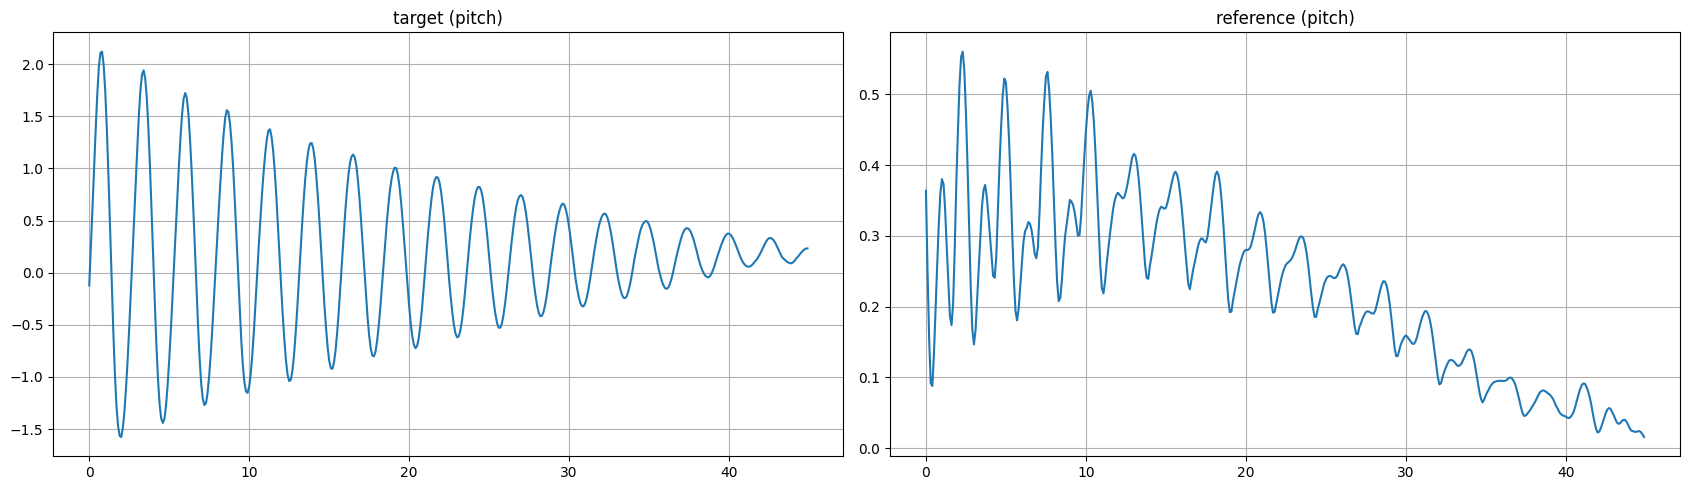

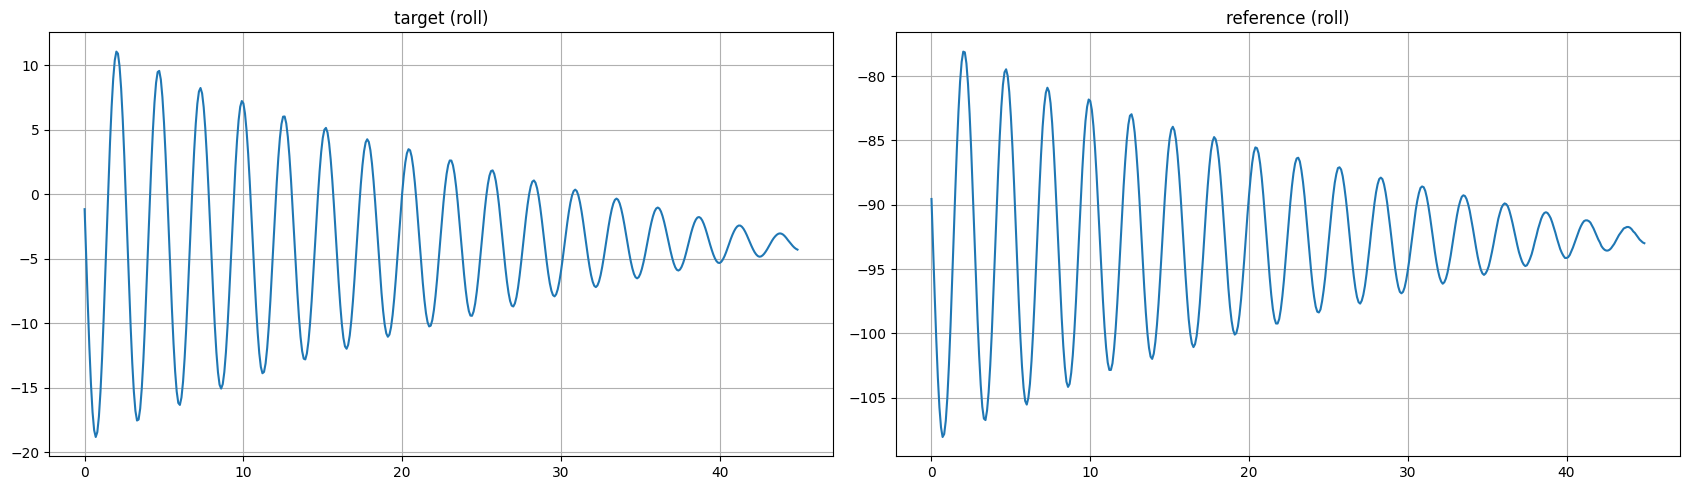

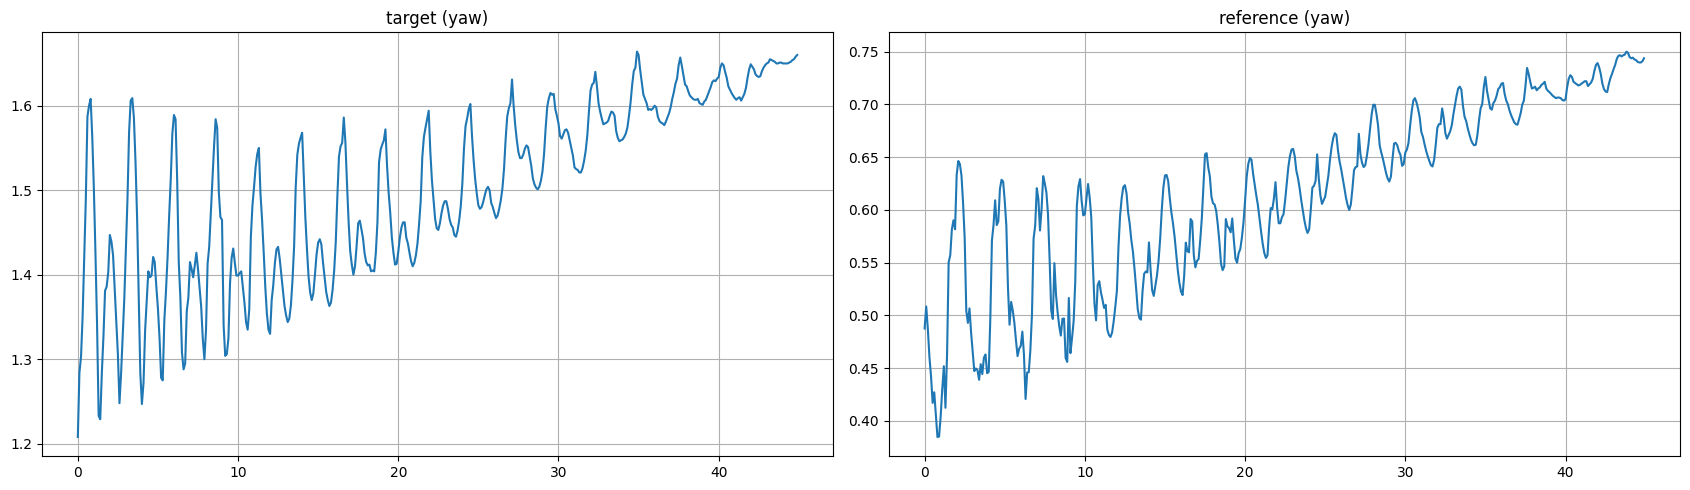

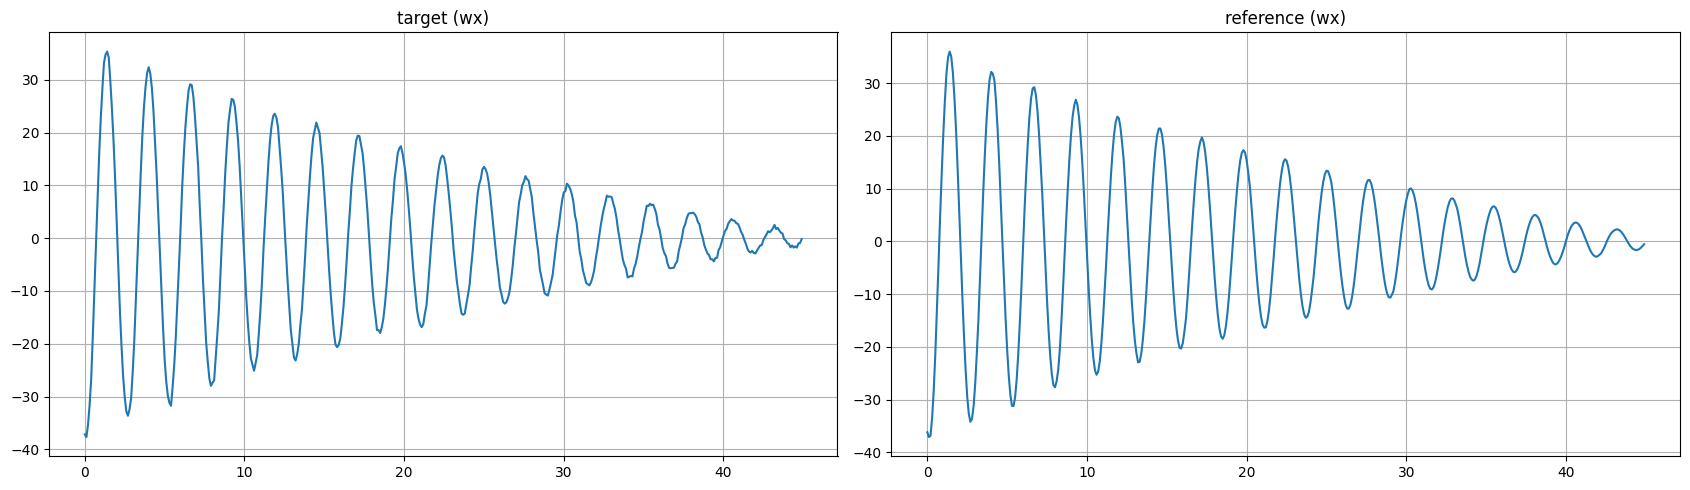

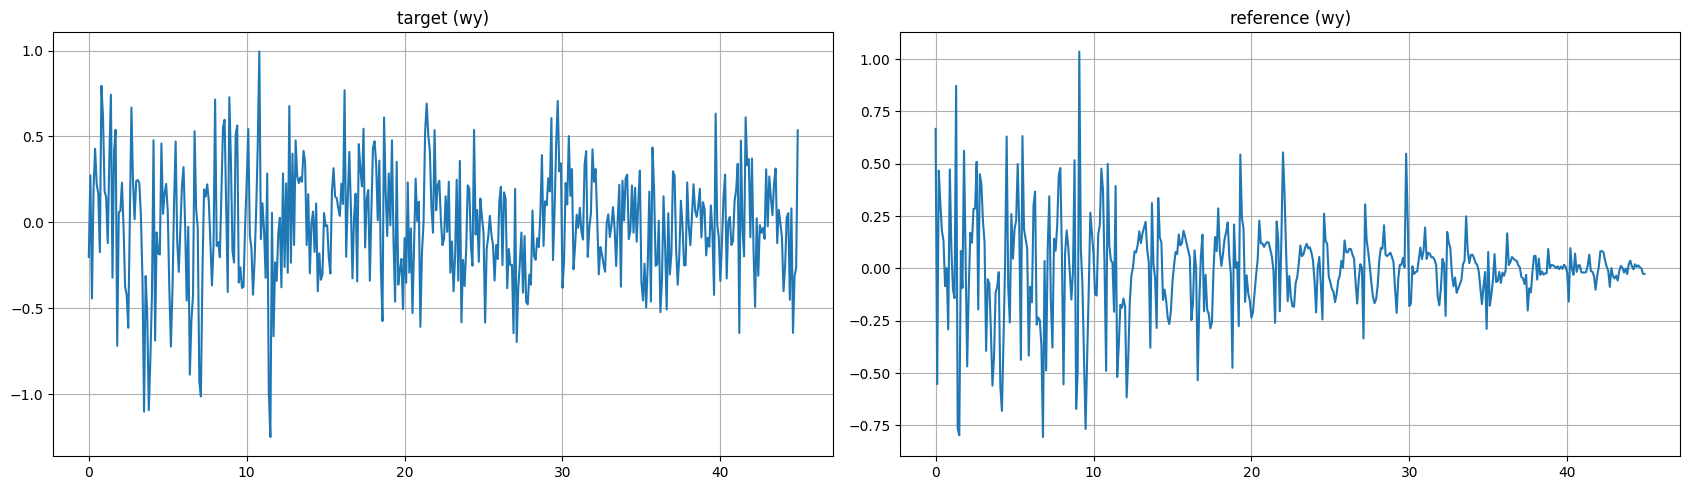

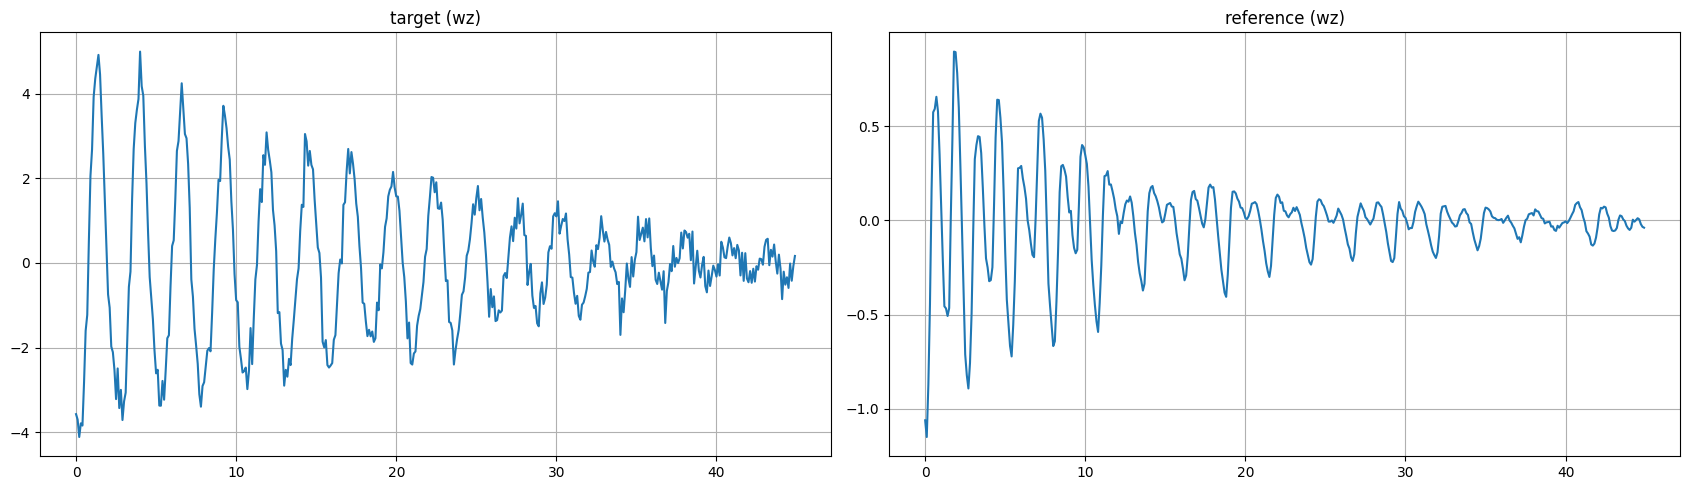

In [22]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target.loc[~df_target.static][f'target_{var}'], 
        f'reference ({var})': df_ref.loc[~df_ref.static][f'ref_{var}']
    }, time=df_ref.loc[~df_ref.static].time, figsize=(17, 5))

In [23]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_pitch,target_e,target_ay,target_roll,target_yaw,target_ax,target_wy,target_az,target_wz,target_wx,target_tmp,static,ref_pitch,ref_q2,ref_q1,ref_ay,ref_roll,ref_yaw,ref_ax,ref_wy,ref_q0,ref_q3,ref_az,ref_wz,ref_wx,ref_sample_time,ref_la_pos_mon_d
0,0.0,-0.121,1.260,10.637460,-1.169,1.208,-0.184816,-0.20151,-0.442486,-3.57567,-37.17227,49.1,False,0.363656,0.000744,0.7044,10.420,-89.553303,0.487587,0.01405,0.666350,-0.7098,-0.005257,0.5907,-1.061691,-36.199473,905000000.0,1.705
1,0.1,0.242,1.224,10.448299,-4.909,1.284,0.439397,0.27387,-0.823160,-3.70565,-37.66696,49.0,False,0.250669,0.001723,0.7269,10.590,-93.277529,0.508385,0.06104,-0.552389,-0.6867,-0.004639,0.5164,-1.150499,-37.104747,5000000.0,1.718
2,0.2,0.617,1.152,10.444965,-8.549,1.303,0.498737,-0.44279,-0.387922,-4.11628,-35.36233,48.8,False,0.154527,0.002290,0.7488,10.630,-97.001755,0.487186,0.10020,0.467247,-0.6628,-0.003830,0.4133,-0.870896,-36.852645,105000000.0,1.723
3,0.3,1.002,1.116,10.572579,-11.886,1.351,0.160594,0.19496,-0.588644,-3.79309,-31.62409,49.2,False,0.091788,0.002575,0.7685,10.530,-100.439501,0.460486,0.17290,0.310371,-0.6399,-0.003188,0.3060,-0.444329,-33.512301,205000000.0,1.721
4,0.4,1.367,1.116,10.269612,-14.729,1.419,0.133920,0.42812,-0.450782,-3.84595,-26.66659,49.1,False,0.088064,0.002552,0.7849,10.330,-103.418882,0.442152,0.21730,0.178706,-0.6196,-0.002995,0.1947,0.159168,-28.349952,305000000.0,1.715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,83.3,0.089,1.656,9.705632,-3.639,2.023,-0.078640,0.14148,-0.670128,-0.38208,0.03454,51.1,True,0.009832,0.006933,0.7229,9.776,-92.589980,1.108673,0.05456,-0.009333,-0.6909,-0.006747,0.4466,0.002871,0.041098,205000000.0,2.300
835,83.4,0.094,1.656,9.764864,-3.634,2.022,-0.030312,-0.06471,-0.430335,0.06300,-0.05436,51.1,True,0.009614,0.006942,0.7228,9.776,-92.589980,1.109819,0.05472,-0.009649,-0.6910,-0.006754,0.4467,0.012771,0.035271,305000000.0,2.296
836,83.5,0.097,1.656,9.778122,-3.628,2.024,-0.058565,0.06451,-0.645689,0.21442,0.35328,51.0,True,0.011362,0.006933,0.7228,9.776,-92.589980,1.109819,0.04937,0.000384,-0.6910,-0.006766,0.4479,0.011144,0.016696,405000000.0,2.292
837,83.6,0.100,1.656,9.715232,-3.626,2.026,0.077982,-0.31530,-0.396267,0.04251,0.15344,50.9,True,0.012674,0.006927,0.7228,9.775,-92.589980,1.110392,0.04573,-0.009952,-0.6910,-0.006777,0.4474,0.019595,0.024884,505000000.0,2.288


In [24]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)